In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
import copy
from sklearn.linear_model import LinearRegression
import sys
sys.path.insert(0, "../")
from RateNeuron import *
from SpikeNeuron import *
from inputFuc import *
from utils import *
from plotting import *

plt.style.use('seaborn-v0_8-white')
mpl.rcParams['font.sans-serif'] = 'Arial'
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['xtick.major.size'] = 3
mpl.rcParams['ytick.major.size'] = 3
mpl.rcParams['lines.linewidth'] = 1.5
mpl.rcParams['axes.prop_cycle'] = plt.cycler(color=[
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', 
    '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
    '#bcbd22', '#17becf'
])

# Visualize Kernel

In [2]:
dt = 0.1
duration = 50
t_steps = int(duration/dt)
#layer index is reversed from end to early

n_hidden1, n_hidden2, n_hidden3 = 4, 4, 4
W1 = np.abs(np.random.randn(n_hidden1, 1).T * 0.2)
W2 = -np.abs(np.random.randn(n_hidden2, n_hidden1).T * 0.2)
W3 = np.abs(np.random.randn(n_hidden3, n_hidden2).T * 0.2)

tau1 = np.random.rand(n_hidden1)*9 + dt
tau2 = np.random.rand(n_hidden2)*9 + dt
tau3 = np.random.rand(n_hidden3)*9 + dt
decay1 = dt/tau1
decay2 = dt/tau2
decay3 = dt/tau3

eps1 = np.zeros((n_hidden1, t_steps))
eps2 = np.zeros((n_hidden2, t_steps))
eps3 = np.zeros((n_hidden3, t_steps))
eps1[:, -1] = W1[0]*1.01 #w1/decay
for step in range(t_steps):
    eps1[:, step] = eps1[:, step-1] * (1-decay1)
    eps2[:, step] = eps2[:, step-1] * (1-decay2) + decay2*W2.T@eps1[:, step]
    eps3[:, step] = eps3[:, step-1] * (1-decay3) + decay3*W3.T@eps2[:, step]

scale1 = W1[0]
scale2 = W2.T@(scale1)
scale3 = W3.T@(scale2)

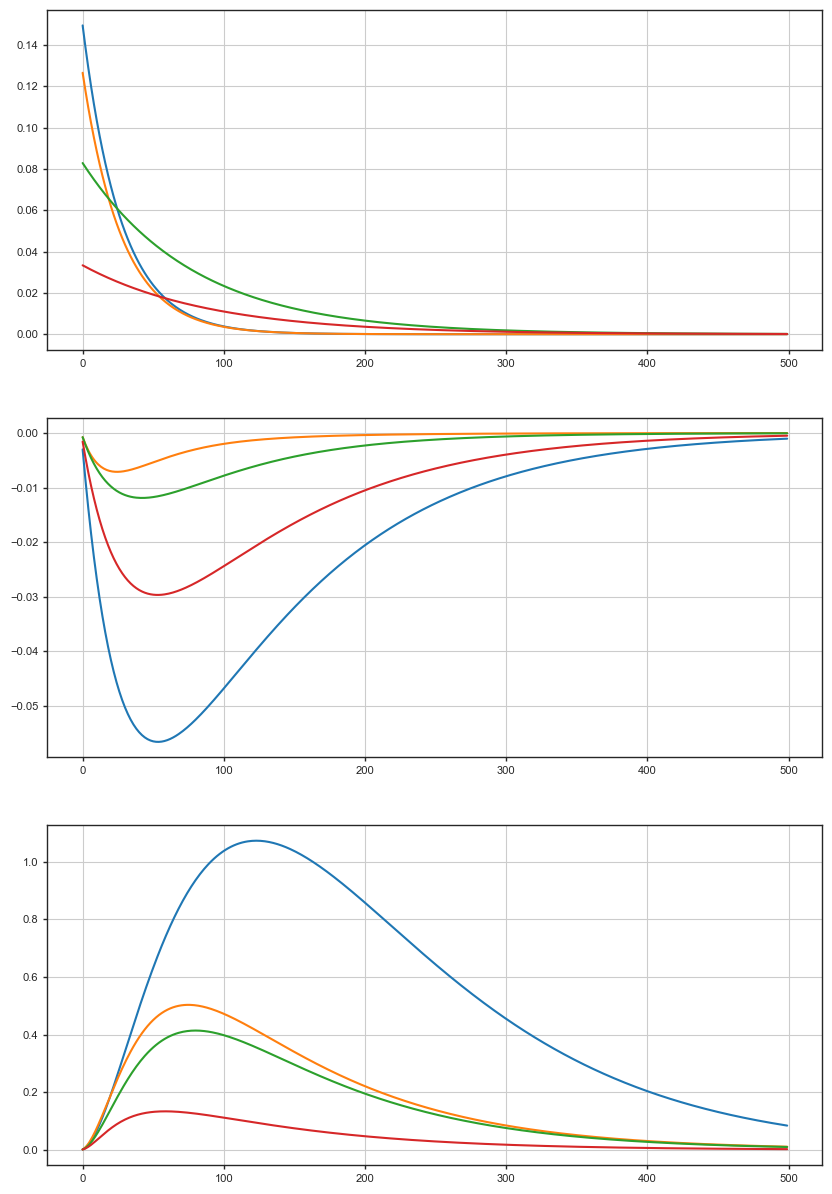

In [4]:
fig, axs = plt.subplots(3, 1, figsize=(10, 15))
for i in range(n_hidden1):
    axs[0].plot(eps1[i])
for i in range(n_hidden2):
    axs[1].plot(eps2[i])
for i in range(n_hidden3):
    axs[2].plot((eps3/np.expand_dims(scale3, 1))[i])
axs[0].grid(True)
axs[1].grid(True)
axs[2].grid(True)

# Kernel propagation with tau-matrix

In [2]:
dt = 0.1
N = [3, 4, 4, 2]
n_out = 1
W = []
for i in range(len(N)-1):
    W.append(np.random.randn(N[i+1], N[i]) * 0.2)
W.append(np.random.randn(n_out, N[-1]) * 0.2)

Tau = [np.random.rand(n)*9 + dt for n in N]
Decay = [dt/tau for tau in Tau]
Tau_flat = np.hstack(Tau)

n_tau = sum(N)
C = np.zeros((n_tau, n_tau))

denom = Tau_flat[None, :]-Tau_flat[:, None]
denom = np.divide(Tau_flat[None, :], denom, where=(denom != 0))
prev_n = 0
for n in N:
    denom[prev_n:prev_n+n, prev_n:prev_n+n] = np.eye(n)
    prev_n+=n

Cl = np.ones((n_out, n_tau))# C from the output layer
for i in reversed(range(len(N))):
    n = N[i]
    Cl = W[i].T @ Cl
    Cl *= denom[prev_n-n:prev_n]
    C[prev_n-n:prev_n, prev_n-n:] = Cl[:, prev_n-n:]
    prev_n-=n

In [51]:
C_reduced = C*(np.abs(C)>1e-3) # reduce number of components
duration = 40
t_steps = int(duration/dt)
DecayFull = np.hstack(Decay)[None:, ]

Exp = np.zeros((t_steps, n_tau, n_tau))
Exp[0] = C*DecayFull
Exp_reduced = np.zeros((t_steps, n_tau, n_tau))
Exp_reduced[0] = C_reduced*DecayFull
for step in range(1, t_steps):
    Exp[step] = Exp[step-1]*(1-DecayFull)
    Exp_reduced[step] = Exp_reduced[step-1]*(1-DecayFull)
Kernel = Exp.sum(axis=-1)
Kernel_reduced = Exp_reduced.sum(axis=-1)

In [52]:
eps = [np.zeros((t_steps, n)) for n in N]
eps1 = [np.zeros((t_steps, n)) for n in N]
eps_ins = [W[-1][0]]
for l in reversed(range(len(N)-1)): 
    eps_ins.insert(0, W[l].T @ (eps_ins[0]))
    
for step in range(t_steps):
    eps[-1][step] = eps[-1][step-1] * (1-Decay[-1]) + Decay[-1] * W[-1] * (step==0)
    eps1[-1][step] = eps1[-1][step-1] * (1-Decay[-1]) + Decay[-1] * (W[-1]/W[-1]) * (step==0)
    
    for l in reversed(range(len(N)-1)):
        eps[l][step] = eps[l][step-1] * (1-Decay[l]) + Decay[l] * (W[l].T @ eps[l+1][step])
        eps1[l][step] = eps1[l][step-1] * (1-Decay[l]) + Decay[l] * ((W[l]/W[l]).T @ eps1[l+1][step])


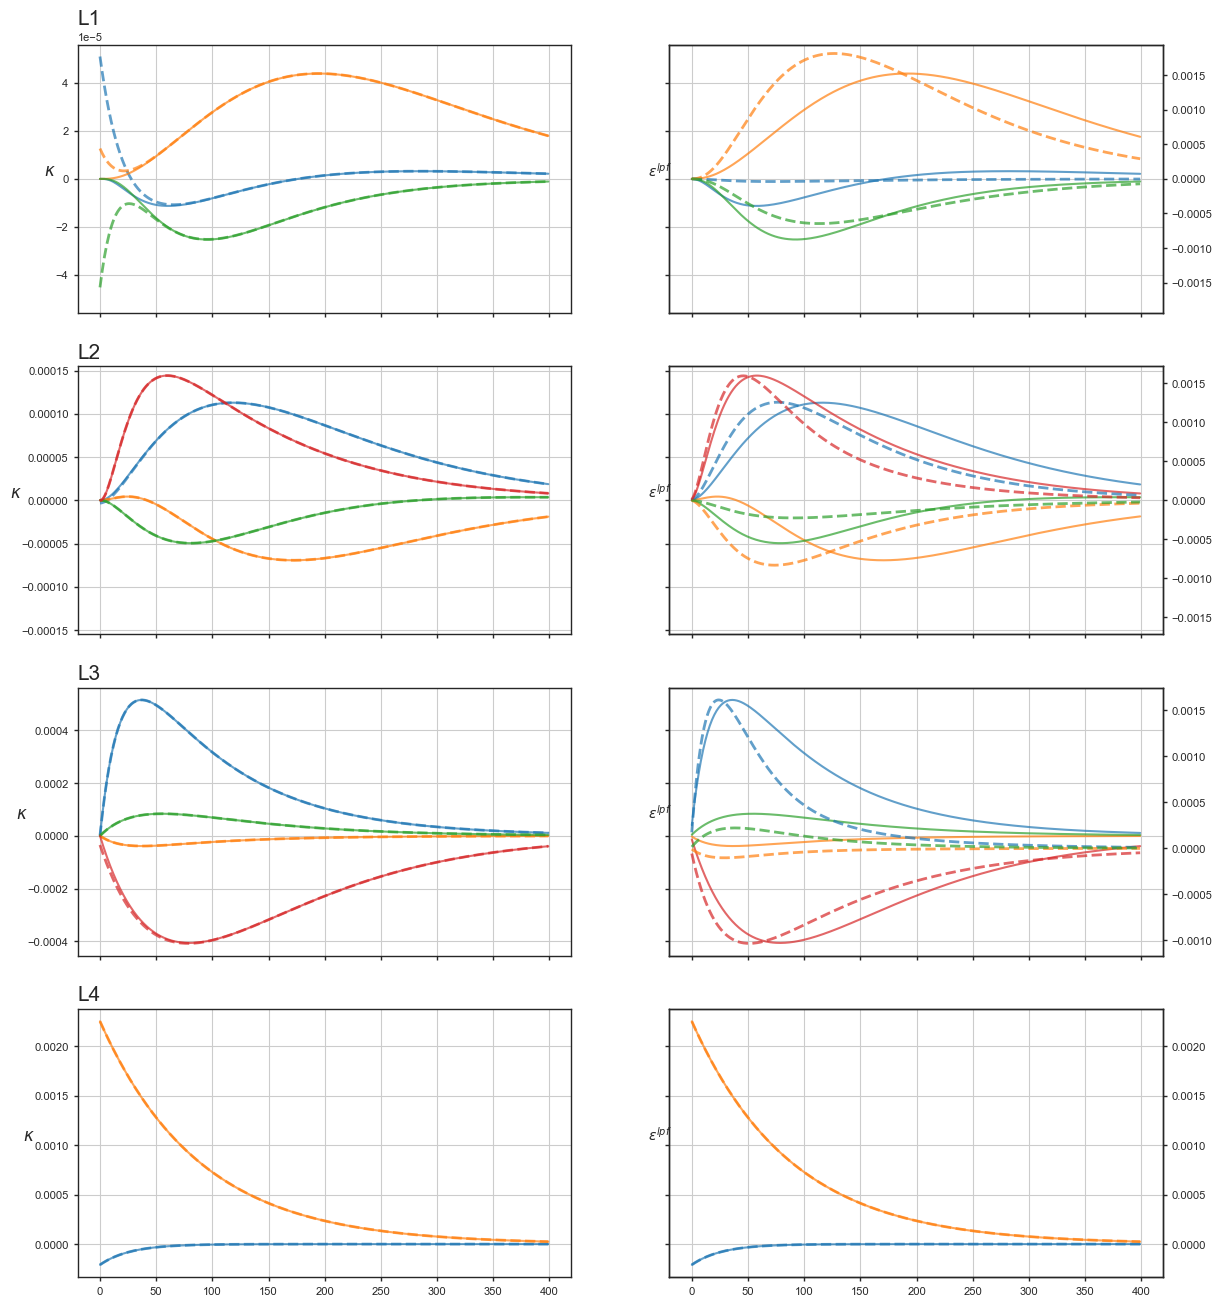

In [53]:
fig, axs = plt.subplots(len(N), 2, figsize=(14, 4*len(N)), sharex='col', sharey='row')
prev_n = 0
for i, n in enumerate(N):
    twin_ax = axs[i, 1].twinx()
    for j in range(n):
        line = axs[i, 0].plot(Kernel[:, prev_n+j], alpha = 0.7)
        axs[i, 0].plot(Kernel_reduced[:, prev_n+j], linestyle='--', alpha = 0.7, linewidth=2., color = line[0].get_color())
        axs[i, 1].plot(eps[i][:, j], alpha = 0.7)
        twin_ax.plot(eps1[i][:, j]*eps_ins[i][j], linestyle='--', alpha = 0.7, linewidth=2.)

    if i < 2:
        ymin, ymax = twin_ax.get_ylim()
        M = max(abs(ymin), abs(ymax))
        twin_ax.set_ylim(-M, M)
        
        ymin, ymax = axs[i, 0].get_ylim()
        M = max(abs(ymin), abs(ymax))
        axs[i, 0].set_ylim(-M, M)
     
    axs[i, 0].set_title('L%d'%(i+1), loc='left', fontsize=15)
    axs[i, 0].set_ylabel(r"$\kappa$", rotation=0, fontsize=12)
    axs[i, 1].set_ylabel(r"$\epsilon^{lpf}$", rotation=0, fontsize=10)
    axs[i, 0].grid(True)
    axs[i, 1].grid(True)
    prev_n += n
plt.show()

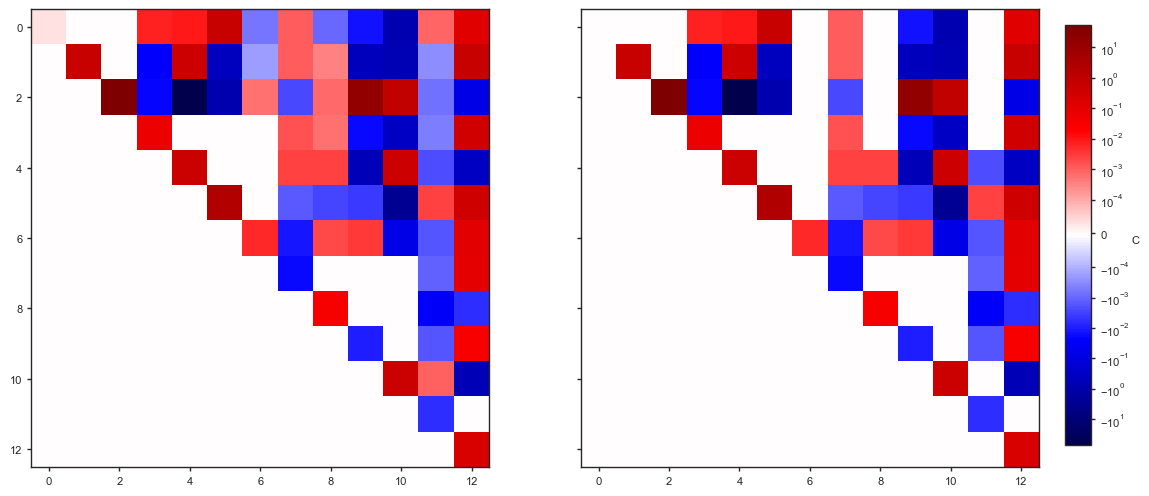

In [38]:
from matplotlib.colors import TwoSlopeNorm, SymLogNorm
C_reduced = C*(np.abs(C)>1e-3)
fig, axs = plt.subplots(1, 2, figsize = (13, 6), sharey=True)
linthresh = 1e-4  # adjust to your data scale

norm = SymLogNorm(linthresh=linthresh, vmin=C.min(), vmax=C.max())

im = axs[0].imshow(C, cmap='seismic', norm=norm)
axs[1].imshow(C_reduced, cmap='seismic', norm=norm)


cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  
cbar = fig.colorbar(im, cax=cbar_ax, shrink=0.9)
cbar.set_label("C", rotation=0)

plt.show()

In [58]:
np.abs(C).sum(axis=1)

array([1.49638614e+00, 3.11533375e+00, 1.42072514e+02, 7.11732322e-01,
       1.77508188e+00, 5.64610951e+00, 2.00965582e-01, 1.08015335e-01,
       6.66001152e-02, 3.73318548e-02, 1.03394074e+00, 5.69155088e-03,
       2.00529429e-01])

# Learning 2 tau on second layer

In [209]:
dt = 0.25
duration = 20000
lr = 1e-1
t_steps = int(duration/dt)
#layer index is reversed from end to early

n_hidden3, n_hidden2, n_hidden1 = 1, 4, 4

W1 = np.abs(np.random.randn(n_hidden1, 1).T * 0.2)
W2 = -np.abs(np.random.randn(n_hidden2, n_hidden1).T * 0.2)
W3 = np.abs(np.random.randn(n_hidden3, n_hidden2).T * 0.2)

tau1 = np.random.rand(n_hidden1)*9 + dt
tau2 = np.random.rand(n_hidden2)*9 + dt
decay1 = dt/tau1
decay2 = dt/tau2

tau_pos_init = 8*np.ones(n_hidden3)
tau_neg_init = 2*np.ones(n_hidden3)
C_init = 3.*np.ones(n_hidden3)
a1 = tau_pos_init+tau_neg_init
a2 = tau_pos_init*tau_neg_init
b = C_init*tau_pos_init - (C_init-1)*tau_neg_init

In [210]:
# -1 layer
eps_lpf1_bar = np.zeros((n_hidden1, t_steps))
eps_inst1 = np.zeros((n_hidden1, t_steps))

#-2 layer
eps_lpf2_bar = np.zeros((n_hidden2, t_steps))
eps_inst2 = np.zeros((n_hidden2, t_steps))

#-3 layer
epsilon_lpf = np.zeros((n_hidden3, t_steps))
epsilon_inst = np.zeros((n_hidden3, t_steps))

Error = np.zeros((n_hidden3, t_steps))
params = []

eps0 = np.random.randn(1, t_steps)
epsilon_lpf_dot=0
for step in range(t_steps):
    eps_lpf1_bar[:, step] = eps_lpf1_bar[:, step-1] * (1-decay1) + decay1*(W1.T@eps0[:, step])
    eps_lpf2_bar[:, step] = eps_lpf2_bar[:, step-1] * (1-decay2) + decay2*(W2.T@eps_lpf1_bar[:, step])
    epsilon_lpf[:, step] = W3.T@eps_lpf2_bar[:, step]
    
    eps_inst1[:, step]  = W1.T@eps0[:, step]
    eps_inst2[:, step]  = W2.T@(decay1*eps_inst1[:, step] )
    epsilon_inst[:, step]  = W3.T@(decay2*eps_inst2[:, step] )

    epsilon_lpf_dot_past = epsilon_lpf_dot
    epsilon_lpf_dot = (epsilon_lpf[:, step] - epsilon_lpf[:, step-1])/dt
    epsilon_lpf_dot_dot = (epsilon_lpf_dot - epsilon_lpf_dot_past)/dt
    epsilon_inst_dot = (epsilon_inst[:, step] - epsilon_inst[:, step-1])/dt

    pred = -a1*epsilon_lpf_dot - a2*epsilon_lpf_dot_dot + b*epsilon_inst[:, step] + a2*epsilon_inst_dot
    error = epsilon_lpf[:, step] - pred
    Error[:, step] = (1-1e-3)*Error[:, step-1] + 1e-3*error
    
    a1 = a1 - lr*error*epsilon_lpf_dot
    a2 = np.clip(a2 + lr**2*error*(epsilon_inst_dot-epsilon_lpf_dot_dot), 1., 100)
    b = b + 200*lr*error*epsilon_inst[:, step]

    params.append([a1, a2, b])


In [211]:
a1, a2, b = params[-1]
ab = np.sqrt(a1**2-4*a2)
tau_pos = (a1+ab)/2
tau_neg = (a1-ab)/2
C = (b-tau_neg)/ab
print(tau_pos, tau_neg, C)

[4.19665447] [3.4524732] [267.32284603]


In [212]:
duration = 50
t_steps = int(duration/dt)

# -1 layer
eps_lpf1_bar = np.zeros((n_hidden1, t_steps))
eps_inst1 = np.zeros((n_hidden1, t_steps))

#-2 layer
eps_lpf2_bar = np.zeros((n_hidden2, t_steps))
eps_inst2 = np.zeros((n_hidden2, t_steps))

#-3 layer
epsilon_lpf = np.zeros((n_hidden3, t_steps))
epsilon_inst = np.zeros((n_hidden3, t_steps))
epsilon_lpf_pred = np.zeros((n_hidden3, t_steps))
epsilon_lpf_pred_init = np.zeros((n_hidden3, t_steps))

eps0 = np.zeros((1, t_steps))
eps0[:, 0] = 1
s_pos, s_neg = 0, 0
s_pos_init, s_neg_init = 0, 0

for step in range(t_steps):
    eps_lpf1_bar[:, step] = eps_lpf1_bar[:, step-1] * (1-decay1) + decay1*(W1.T@eps0[:, step])
    eps_lpf2_bar[:, step] = eps_lpf2_bar[:, step-1] * (1-decay2) + decay2*(W2.T@eps_lpf1_bar[:, step])
    epsilon_lpf[:, step] = W3.T@eps_lpf2_bar[:, step]
    
    eps_inst1[:, step]  = W1.T@eps0[:, step]
    eps_inst2[:, step]  = W2.T@(decay1*eps_inst1[:, step])
    epsilon_inst[:, step]  = W3.T@(decay2*eps_inst2[:, step])

    s_pos = s_pos*(1-dt/tau_pos) + C*epsilon_inst[:, step]
    s_neg = s_neg*(1-dt/tau_neg) + (C-1)*epsilon_inst[:, step]
    epsilon_lpf_pred[:, step] = s_pos-s_neg

    s_pos_init = s_pos_init*(1-dt/tau_pos_init) + C_init*epsilon_inst[:, step]
    s_neg_init = s_neg_init*(1-dt/tau_neg_init) + (C_init-1)*epsilon_inst[:, step]
    epsilon_lpf_pred_init[:, step] = s_pos_init-s_neg_init

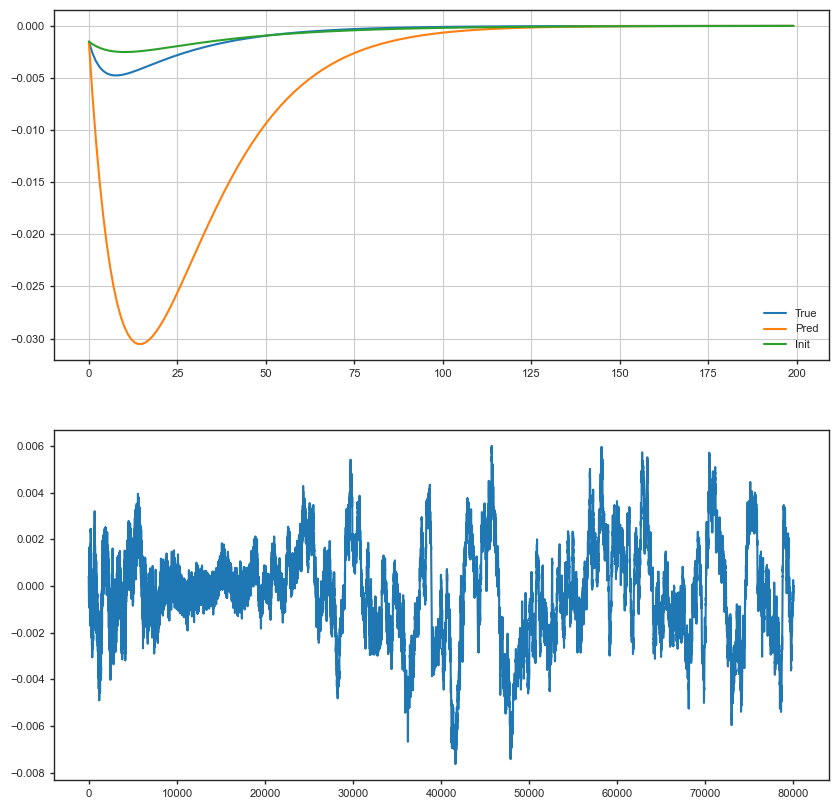

In [213]:
fig, axs = plt.subplots(2, 1, figsize=(10, 10))
for i in range(n_hidden3):
    axs[0].plot(epsilon_lpf[i], label='True')
    axs[0].plot(epsilon_lpf_pred[i], label='Pred')
    axs[0].plot(epsilon_lpf_pred_init[i], label='Init')
    axs[1].plot(Error[i])
axs[0].grid(True)
axs[0].legend()

